In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math
import numpy as np

In [2]:
datos, metadatos = tfds.load('fashion_mnist', as_supervised=True, with_info=True)

In [3]:
metadatos

tfds.core.DatasetInfo(
    name='fashion_mnist',
    full_name='fashion_mnist/3.0.1',
    description="""
    Fashion-MNIST is a dataset of Zalando's article images consisting of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes.
    """,
    homepage='https://github.com/zalandoresearch/fashion-mnist',
    data_dir='C:\\Users\\juan carlos\\tensorflow_datasets\\fashion_mnist\\3.0.1',
    file_format=tfrecord,
    download_size=29.45 MiB,
    dataset_size=36.42 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@articl

In [4]:
datos_entrenamiento, datos_pruebas = datos['train'], datos['test']

In [5]:
nombres_clases = metadatos.features['label'].names
print(nombres_clases)

['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [6]:
def normalizar(imagenes, etiquetas):
    imagenes = tf.cast(imagenes, tf.float32)
    imagenes /= 255
    return imagenes, etiquetas

datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

In [7]:
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

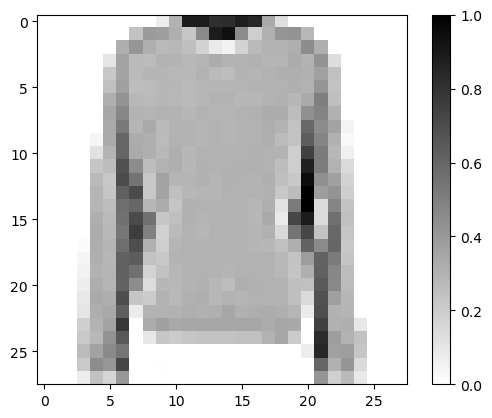

In [8]:
for imagen, etiqueta in datos_entrenamiento.take(1):
    break

imagen = imagen.numpy().reshape((28,28))

plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

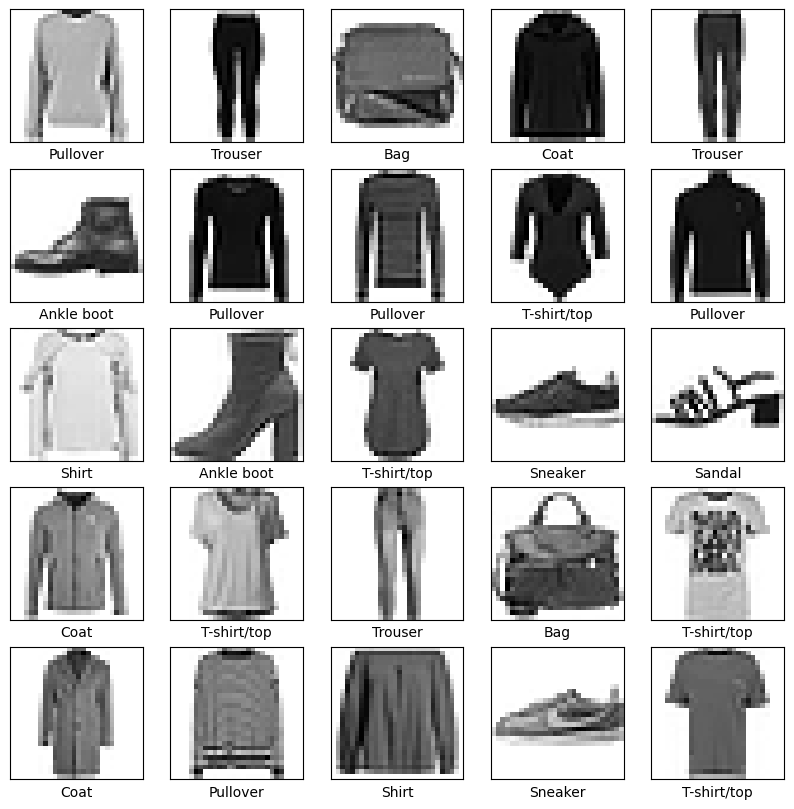

In [9]:
plt.figure(figsize=(10,10))

for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
    imagen = imagen.numpy().reshape((28,28))
    
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(imagen, cmap=plt.cm.binary)
    plt.xlabel(nombres_clases[etiqueta])

plt.show()

In [10]:
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=(28,28,1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(50, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [11]:
modelo.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [12]:
TAMANO_LOTE = 32

num_ej_entrenamiento = metadatos.splits['train'].num_examples
num_ej_pruebas = metadatos.splits['test'].num_examples

print("Ejemplos de entrenamiento:", num_ej_entrenamiento)
print("Ejemplos de prueba:", num_ej_pruebas)

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(num_ej_entrenamiento).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

Ejemplos de entrenamiento: 60000
Ejemplos de prueba: 10000


In [13]:
historial = modelo.fit(
    datos_entrenamiento,
    epochs=5,
    steps_per_epoch=math.ceil(num_ej_entrenamiento / TAMANO_LOTE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.8173 - loss: 0.5218
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8612 - loss: 0.3803
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8702 - loss: 0.3505
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8805 - loss: 0.3263
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8852 - loss: 0.3092


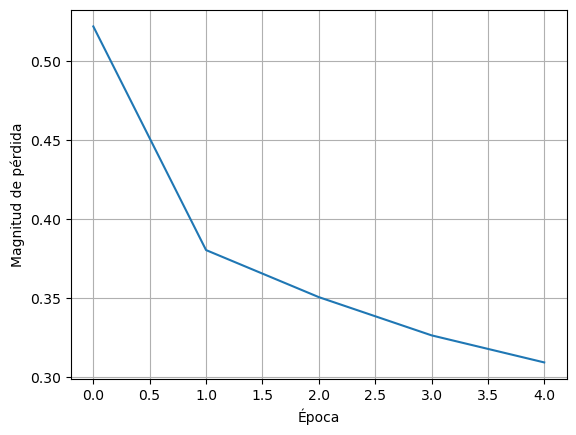

In [14]:
plt.figure()
plt.xlabel("Época")
plt.ylabel("Magnitud de pérdida")
plt.plot(historial.history["loss"])
plt.grid(True)
plt.show()

In [15]:
for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
    imagenes_prueba = imagenes_prueba.numpy()
    etiquetas_prueba = etiquetas_prueba.numpy()

predicciones = modelo.predict(imagenes_prueba)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step


In [16]:
def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
    arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img[...,0], cmap=plt.cm.binary)

    etiqueta_prediccion = np.argmax(arr_predicciones)

    if etiqueta_prediccion == etiqueta_real:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(
        nombres_clases[etiqueta_prediccion],
        100*np.max(arr_predicciones),
        nombres_clases[etiqueta_real]),
        color=color
    )

In [17]:
def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]

    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])

    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])

    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

In [18]:
def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]

    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])

    grafica = plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])

    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

In [19]:
imagen = blusa.png[24]
imagen = np.array([imagen])

prediccion = modelo.predict(imagen)

print("Predicción:", nombres_clases[np.argmax(prediccion[0])])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
Predicción: T-shirt/top


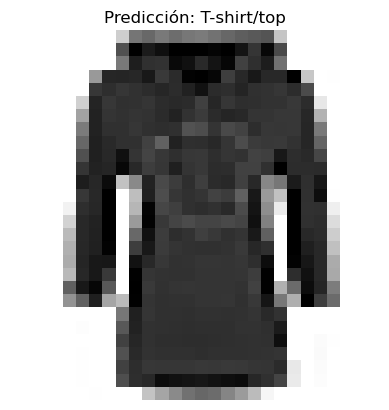

In [20]:
plt.figure()
plt.imshow(imagen[0][...,0], cmap=plt.cm.binary)
plt.title("Predicción: " + nombres_clases[np.argmax(prediccion[0])])
plt.axis('off')
plt.show()

In [21]:
modelo.save("modelo_ropa.h5")
print("Modelo guardado correctamente en formato h5")

Modelo guardado correctamente en formato h5


In [22]:
from tensorflow.keras.preprocessing import image

In [32]:
import os
os.getcwd()

'C:\\Users\\juan carlos'

In [33]:
ruta_imagen = "blusa.png.webp"
import os
os.getcwd()

img = image.load_img(ruta_imagen, target_size=(28,28), color_mode='grayscale')
img_array = image.img_to_array(img)


FileNotFoundError: [Errno 2] No such file or directory: 'blusa.png.webp'

In [28]:
## as_supervised: Permite cargar el dataset en formato supervisado, es decir, separando cada dato en entrada y salida, o sea imagen y etiqueta.

##with_info: Permite obtener información adicional del dataset, como metadatos, número de ejemplos y nombres de las clases.

##map(): Se utiliza para aplicar una función a cada elemento del dataset. En este caso se usa para normalizar las imágenes.

## Formato h5: Es un formato de archivo utilizado para guardar modelos entrenados de aprendizaje automático, incluyendo su arquitectura, pesos y configuración.##